<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-10 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Simple AutoEncoders with Image Data </h2> </html>

Here is a simple autoencoder with just the dense layers.


Load the data and import the libraries.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib import *
import seaborn as sns


_______________________![image.png](attachment:a4e07154-e766-4e74-a203-c09e7605ea7b.png)

In [2]:
import tensorflow as tf
from tensorflow import keras

__________________![image.png](attachment:06d151d2-f461-411d-8325-a4a6287cfd48.png)

In [3]:
print(tf.__version__)

2.19.0


____________________![image.png](attachment:3ff556fc-1f76-4be4-a216-1e8aecd11e54.png)

In [4]:
from keras.layers import Input, Dense
from keras.models import Model

In [5]:
from keras.datasets import mnist

In [6]:
# Load data (ignore labels)
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize (0–255 → 0–1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Check shapes
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


______________________![image.png](attachment:74823cdf-09eb-4a7a-8a39-8c306d6de031.png)

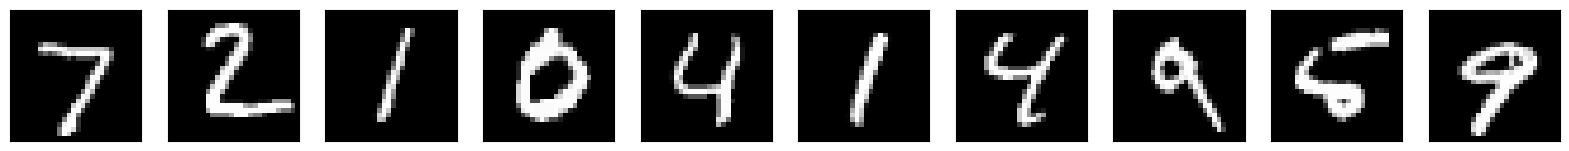

In [7]:
# Plot a few data points
%matplotlib inline

n = 10  # Number of records that will display
plt.figure(figsize=(20, 4))

for i in range(n):

    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [8]:
# Normalize train data (0–255 → 0–1)
x_train = x_train.astype('float32') / 255.

# Normalize test data (0–255 → 0–1)
x_test = x_test.astype('float32') / 255.


<html> <h3 style="font-style:italic; color:blue;"> Basic AutoEncoder : </h3> </html>

Build a basic symmetric encoder-decoder network that recreates the image.  
This network could be used in dimensionaliry reduction or feature learning.


________________________![image.png](attachment:de80ae8e-d8d5-4cfc-a51b-a2f7d50dc7c2.png)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import SGD

In [10]:
encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))

# Flatten image
encoder.add(Flatten())

# Hidden layers
encoder.add(Dense(128, activation='relu'))
encoder.add(Dense(64, activation='relu'))

# Latent space (MUST match decoder input = 25)
encoder.add(Dense(25, activation='relu'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
encoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,361 (431.10 KB)

 Trainable params: 110,361 (431.10 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Your OWN Encoder model should be printed here
# Please do not copy the model below

In [13]:
decoder = Sequential()
decoder.add(Dense(50,input_shape=[25],activation='relu'))

# Mirror encoder
decoder.add(Dense(64, activation='relu'))
decoder.add(Dense(128, activation='relu'))

# Output layer
decoder.add(Dense(28 * 28, activation='sigmoid'))

# Reshape back to image
decoder.add(Reshape((28, 28)))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
decoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,020 (445.39 KB)

 Trainable params: 114,020 (445.39 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Your OWN Decoder model should be printed here
# Please do not copy the model below

____________________![image.png](attachment:a94c2e5b-e27d-4e12-84c9-116a2f70e393.png)

In [16]:
autoencoder = Sequential([encoder, decoder])

In [17]:
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 25)             │       110,361 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │       114,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,381 (876.49 KB)

 Trainable params: 224,381 (876.49 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Your code to print the Autoencoder model

#

In [19]:
# Your OWN Autoencoder model should be printed here

In [20]:
#SGD?

In [21]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


___________________![image.png](attachment:c8684fc7-fcb0-48bf-87e8-f70857a0fc4e.png)

In [22]:
history = autoencoder.fit(
    x_train, x_train,
    epochs=20,
    validation_data=(x_test, x_test)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.0661 - loss: 0.0146 - val_accuracy: 0.0694 - val_loss: 0.0040
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0695 - loss: 0.0039 - val_accuracy: 0.0730 - val_loss: 0.0040
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0848 - loss: 0.0039 - val_accuracy: 0.0954 - val_loss: 0.0039
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0947 - loss: 0.0039 - val_accuracy: 0.0977 - val_loss: 0.0039
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1043 - loss: 0.0039 - val_accuracy: 0.1093 - val_loss: 0.0039
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1243 - loss: 0.0038 - val_accuracy: 0.1378 - val_loss: 0.0039
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.1371 - loss: 0.0038 - val_accuracy: 0.1391 - val_loss: 0.0038
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1453 - loss: 0.0038 -

____________________![image.png](attachment:30a3bc58-49bd-4849-8c76-e2551d3a033b.png)

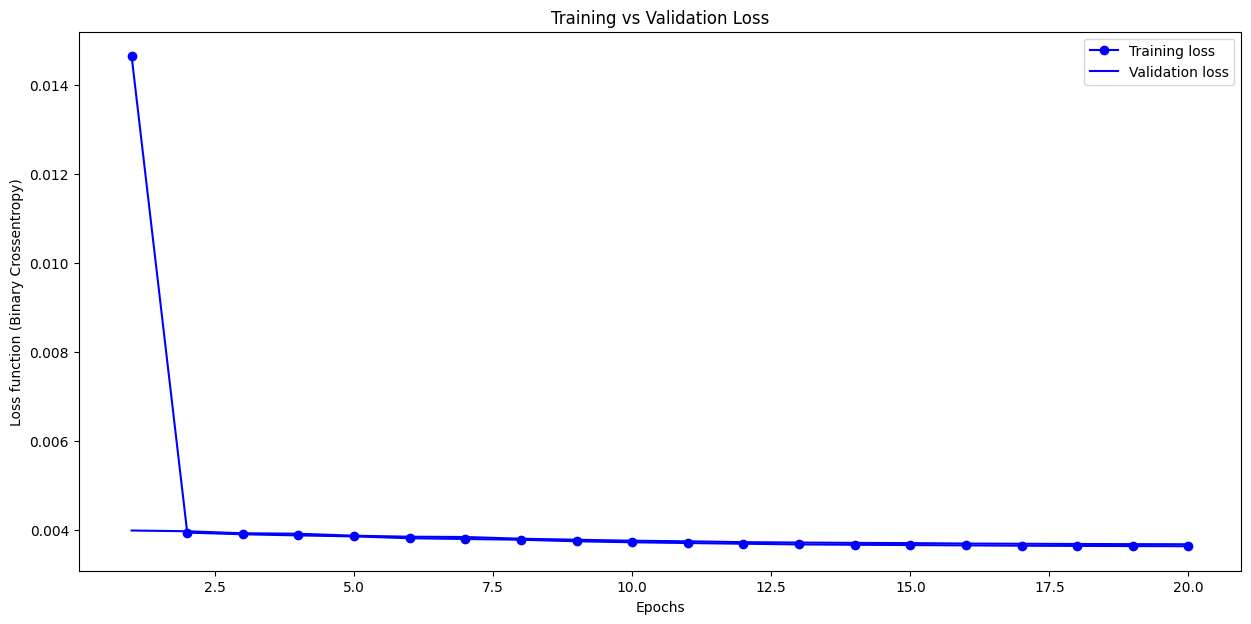

In [23]:
losses = history.history['loss']
val_losses = history.history['val_loss']

epochs = range(1, len(losses) + 1)

# Plot
plt.figure(figsize=(15, 7))
plt.plot(epochs, losses, 'bo-', label='Training loss')
plt.plot(epochs, val_losses, 'b', label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss function (Binary Crossentropy)')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

___________________![image.png](attachment:b2f19fbc-57fa-40f7-80a1-336642829de1.png)

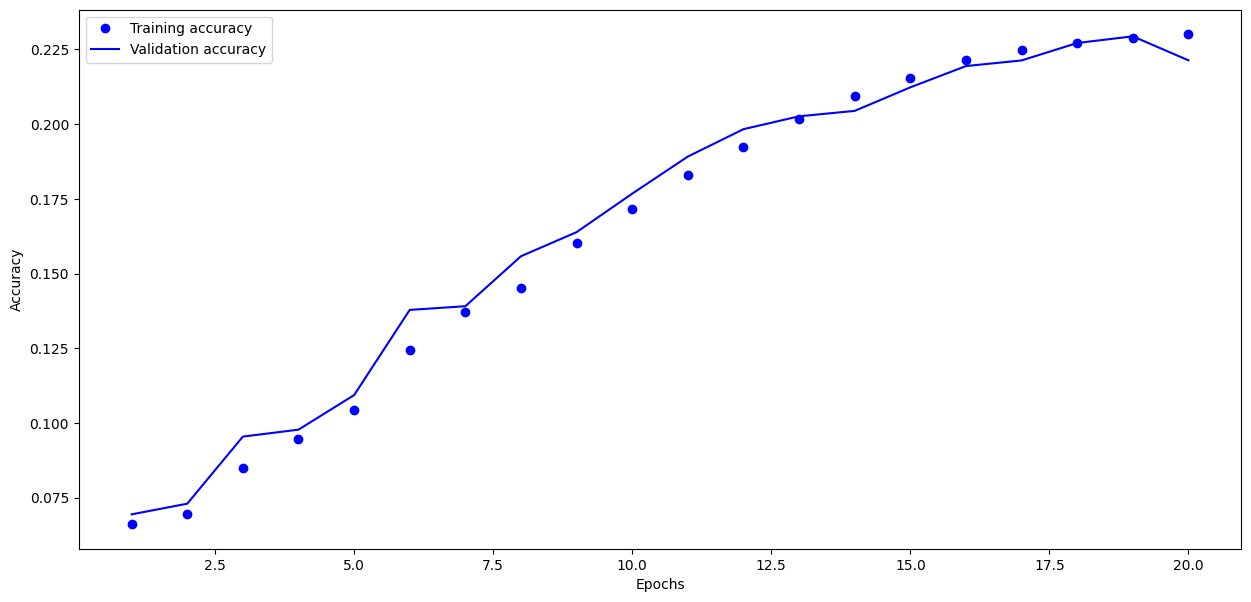

In [24]:
# Plot accuracy and val_accuracy for the neural network training process in detail

accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(num=1, figsize=(15, 7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

_______________________![image.png](attachment:39f152ac-8692-403f-a1c4-3a71fe4fd978.png)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


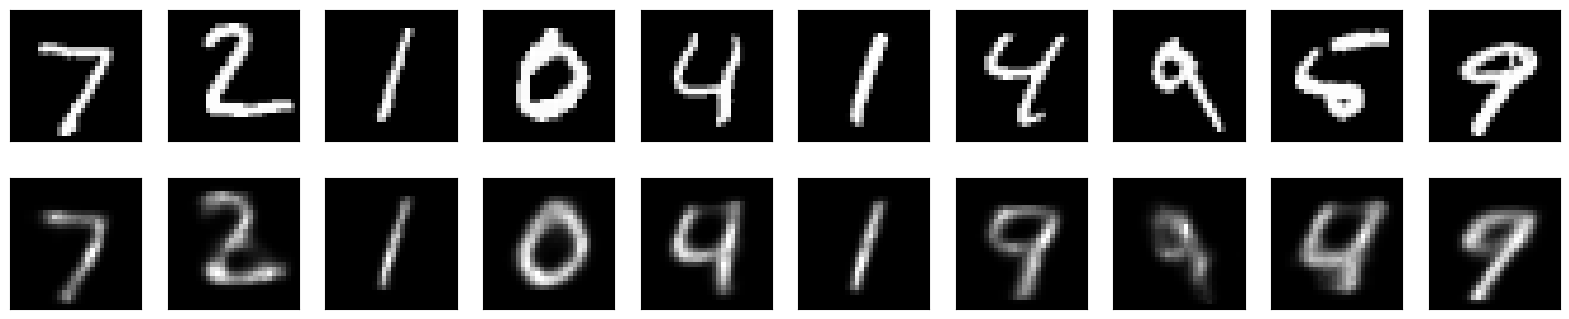

In [25]:
decoded_imgs = autoencoder.predict(x_test)

n = 10

plt.figure(figsize=(20, 4))

for i in range(n):

    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed (decoded) images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

<html> <h3 style="font-style:italic; color:blue;"> AutoEncoders for Denoising Images : </h3> </html>

Use the same digit data set. Add Gaussian noise to it to train an autoencoder that removes noise. Test the noisy samples.


______________________![image.png](attachment:66c883c0-27ea-473a-bfbf-adf60d8af39f.png)

In [26]:
from tensorflow.keras.layers import GaussianNoise

In [27]:
#GaussianNoise?

___________________![image.png](attachment:daef4479-63f7-4a6a-9927-be13f2230632.png)

In [28]:
sample = GaussianNoise(0.2)
noisey = sample(x_test[0:2], training=True)

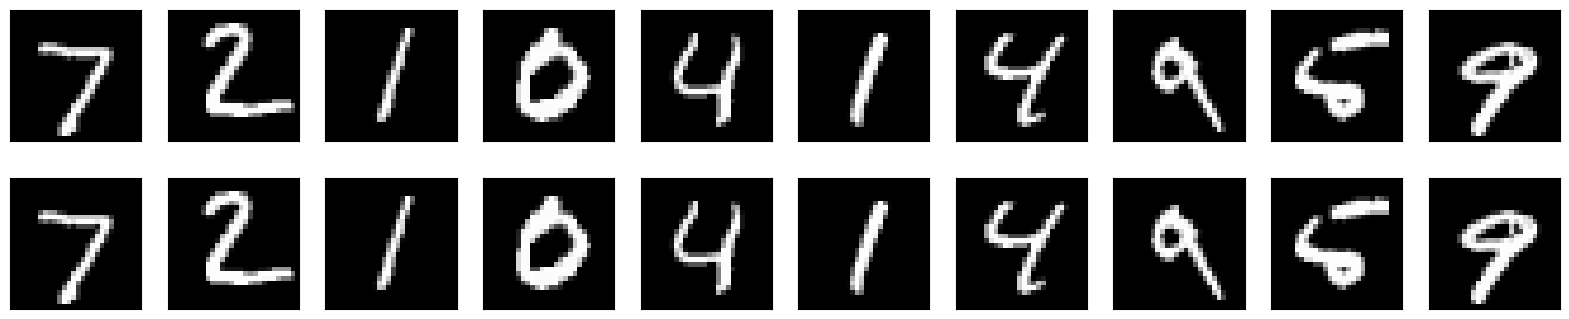

In [29]:
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):

    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Noisy images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test[i], cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

_______________________![image.png](attachment:4013cb09-7c0a-4cc7-b208-31bda1d0f668.png)

In [30]:
x_test[0].size

784

____________________![image.png](attachment:2e2bac52-3120-4879-9117-f71bdf1ac965.png)

<function matplotlib.pyplot.show(close=None, block=None)>

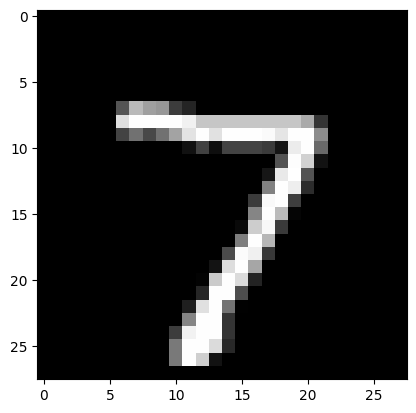

In [31]:
plt.imshow(x_test[0])
plt.show

_____________________![image.png](attachment:003958e0-35f7-4d32-8faf-b9486b5d206f.png)

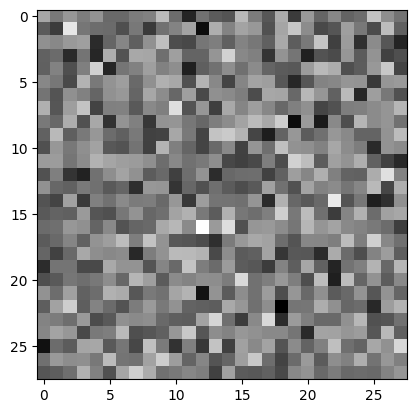

In [32]:
plt.imshow(noisey[0])
plt.show()

_________![image.png](attachment:dd745f81-2f9e-4b45-b030-3a4529ea6f1d.png)

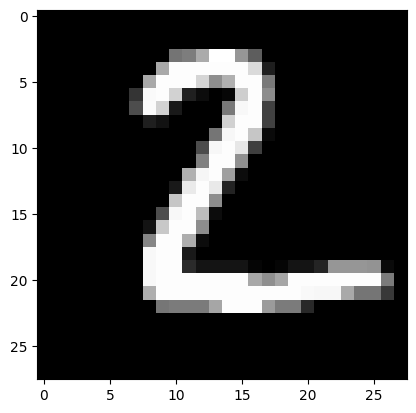

In [33]:
plt.imshow(x_test[1])
plt.show()

______________________![image.png](attachment:cf4f913b-10d4-47b9-9d91-b22fd1c175fa.png)

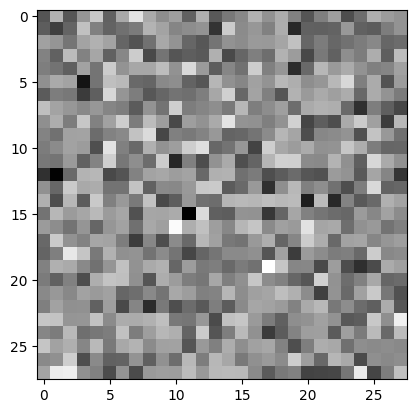

In [34]:
plt.imshow(noisey[1])
plt.show()

<html> <h4 style="font-style:italic; color:blue;"> Create a noise removal autoencoder and train it </h4> </html>

- Again similar to above it is a symmetric dense network.
- Gaussian noise is added at the input so that the network sees noisy images and is able to map it to the clean outputs.


### Input - Images with noise
### Labels - Clean images.


In [35]:
# Encoder

encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))
encoder.add(GaussianNoise(0.2)) # We are adding noise to make input as noisy images
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, GaussianNoise


# Hidden layers
encoder.add(Dense(128, activation='relu'))
encoder.add(Dense(64, activation='relu'))

# MUST end with 25 to match decoder
encoder.add(Dense(25, activation='relu'))

print(encoder.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_1                │ (None, 784)            │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,361 (431.10 KB)

 Trainable params: 110,361 (431.10 KB)

 Non-trainable params: 0 (0.00 B)

None


In [36]:
# Your OWN Encoder model should be printed here
# Please do not copy the model below

In [37]:
decoder = Sequential()
decoder.add(Dense(50,input_shape=[25],activation='relu'))

# Add layers
decoder.add(Dense(64, activation='relu'))
decoder.add(Dense(128, activation='relu'))


decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))

print(decoder.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 50)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,020 (445.39 KB)

 Trainable params: 114,020 (445.39 KB)

 Non-trainable params: 0 (0.00 B)

None


In [38]:
# Your OWN Decoder model should be printed here
# Please do not copy the model below

_________________________![image.png](attachment:b8742807-43dd-41a1-a461-c2a4455e6d07.png)

In [39]:
noise_remover = Sequential([encoder, decoder])

In [40]:
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 25)             │       110,361 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28)         │       114,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,145 (2.57 MB)

 Trainable params: 224,381 (876.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 448,764 (1.71 MB)

In [41]:
# Your OWN Autoencoder model should be printed here

In [45]:
noise_remover.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [47]:
sample = GaussianNoise(0.2)

x_train_noisy = sample(x_train, training=True)
x_test_noisy = sample(x_test, training=True)

history_2 = noise_remover.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test_noisy, x_test)
)


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.0471 - loss: 0.0577 - val_accuracy: 0.0615 - val_loss: 0.0053
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0672 - loss: 0.0042 - val_accuracy: 0.0674 - val_loss: 0.0054
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0671 - loss: 0.0040 - val_accuracy: 0.0689 - val_loss: 0.0054
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0671 - loss: 0.0040 - val_accuracy: 0.0683 - val_loss: 0.0054
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0671 - loss: 0.0040 - val_accuracy: 0.0677 - val_loss: 0.0053
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0675 - loss: 0.0040 - val_accuracy: 0.0695 - val_loss: 0.0053
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0674 - loss: 0.0040 - val_accuracy: 0.0666 - val_loss: 0.0053
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0673 - loss: 0.0040 - val_accuracy: 0

In [44]:
# Hint: Use (copy and modify) the code from the cells above

___________________![image.png](attachment:05682556-9ec1-46c6-85d5-3db97ba3c04f.png)

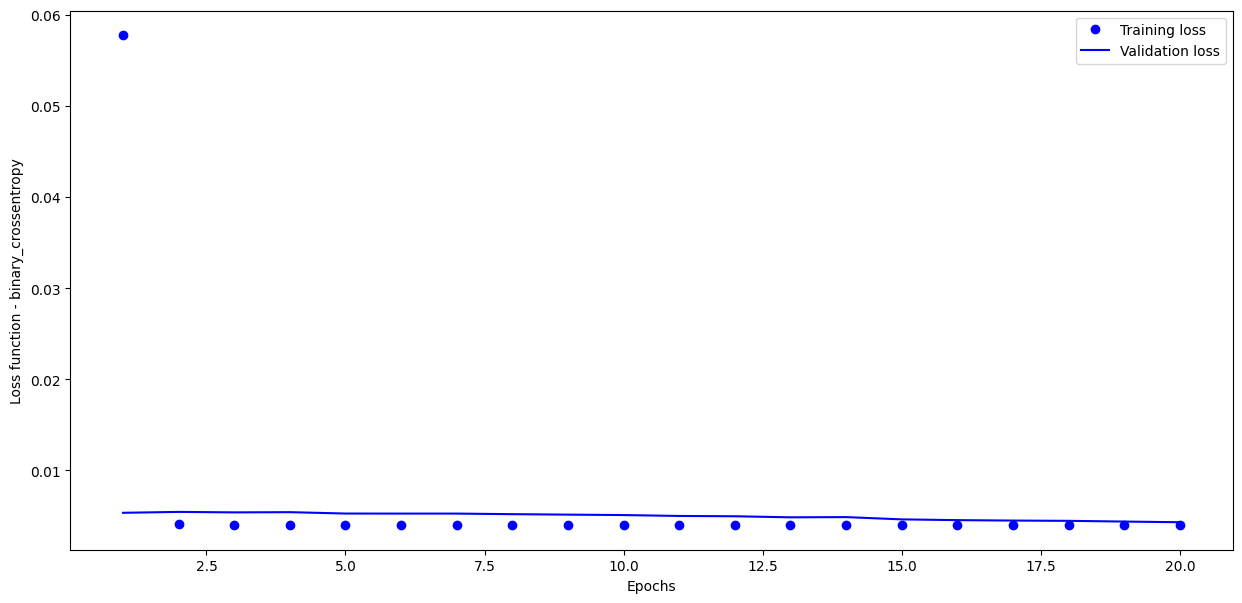

In [48]:
losses = history_2.history['loss']
losses_val = history_2.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15, 7))
plt.plot(epochs, losses, 'bo', label='Training loss')
plt.plot(epochs, losses_val, 'b', label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss function - binary_crossentropy')
plt.legend()

plt.show()

___________________________![image.png](attachment:43697532-dcb7-41bf-a1fa-6f630f5d4a29.png)

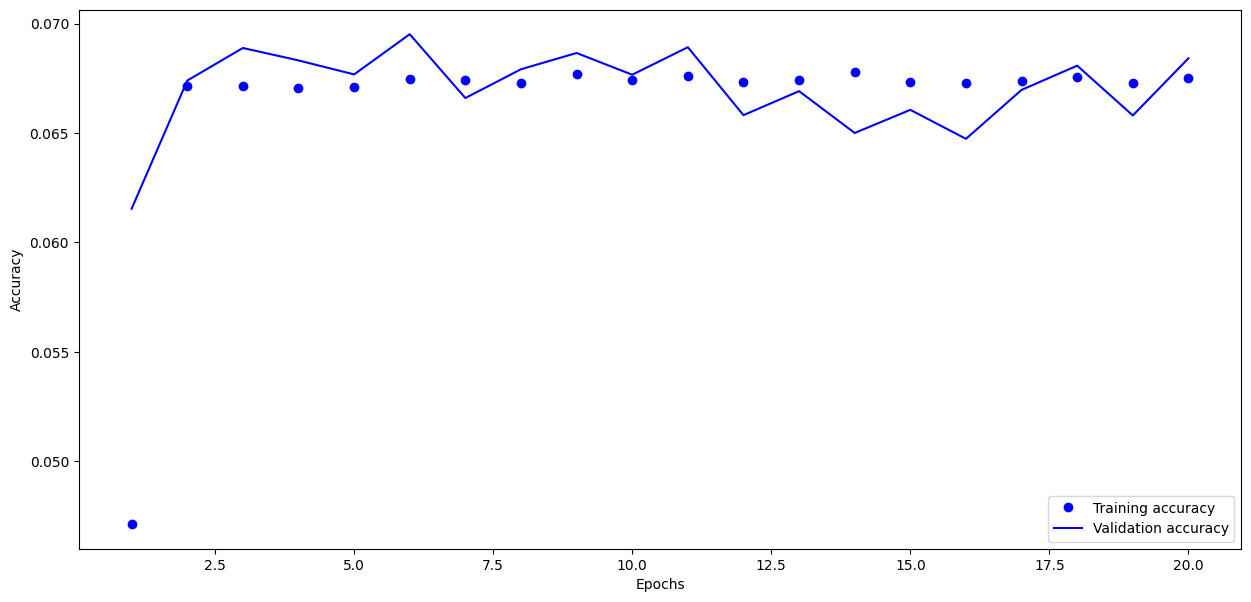

In [49]:
accuracy_array = history_2.history['accuracy']
val_accuracy_array = history_2.history['val_accuracy']
epochs = range(1, len(accuracy_array) + 1)

plt.figure(num=1, figsize=(15, 7))
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

______________________![image.png](attachment:9dbf1489-73d6-4480-adc7-0ced14e0c9dd.png)

In [50]:
hundred_noisey_images = sample(x_test[0:100], training=True)

denoised = noise_remover(hundred_noisey_images[0:100])

______________________![image.png](attachment:a5bc2008-bc25-45e7-97ba-ae44dffae6ed.png)

In [51]:
import random

_______![image.png](attachment:505ed502-6fd8-4f58-a27f-44a804f20493.png)

74
The Original


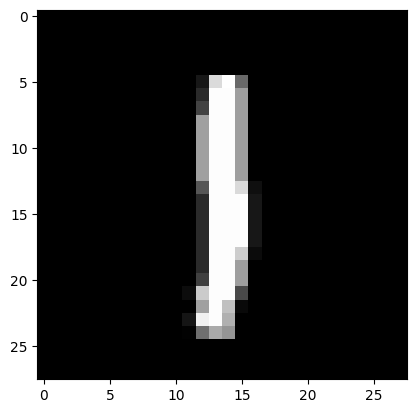

The Noisey Version


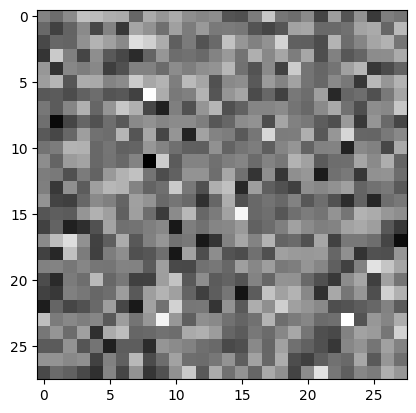

After going through denoiser


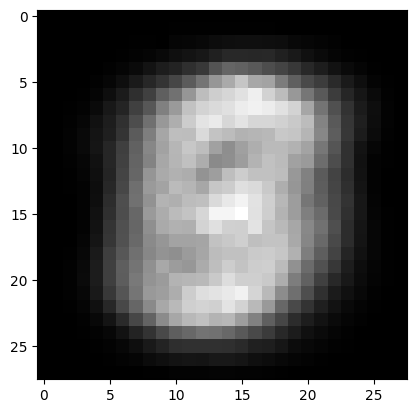

In [52]:
import random

n = random.randint(0, 100)

print(n)

print("The Original")
plt.imshow(x_test[n])
plt.show()

print("The Noisey Version")
plt.imshow(hundred_noisey_images[n])
plt.show()

print("After going through denoiser")
plt.imshow(denoised[n])
plt.show()

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

 - Put the Encoder, Decoder and Basic Autoencoder models using summary() in your lab logbook.

Ensure that no code or other information is added to the logbook and that only required information is present. Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.

NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE.